In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler

In [3]:
with open ("D:\\Source file\\spambase\\spambase.names",'r') as spam:
    lines=spam.readlines()


In [4]:
columns=[]
for line in lines:
    line = line.strip()
    if ":" in line and not line.startswith("|") and not line.startswith("1,"):
        col_name= line.split(":")[0].strip()
        columns.append(col_name)
    

columns.append("is_spam")

print("columns extracted :",len(columns))

df=pd.read_csv("D:\\Source file\\spambase\\spambase.data",header=None,names=columns)

columns extracted : 58


In [5]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [6]:
df.tail()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
4596,0.31,0.0,0.62,0.0,0.00,0.31,0.0,0.0,0.0,0.0,...,0.000,0.232,0.0,0.000,0.0,0.0,1.142,3,88,0
4597,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.353,0.0,0.0,1.555,4,14,0
4598,0.30,0.0,0.30,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.102,0.718,0.0,0.000,0.0,0.0,1.404,6,118,0
4599,0.96,0.0,0.00,0.0,0.32,0.00,0.0,0.0,0.0,0.0,...,0.000,0.057,0.0,0.000,0.0,0.0,1.147,5,78,0
4600,0.00,0.0,0.65,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.125,0.0,0.0,1.250,5,40,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [8]:
df["is_spam"].value_counts()

is_spam
0    2788
1    1813
Name: count, dtype: int64

In [9]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [10]:
corr=df.corr()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sea

<Axes: >

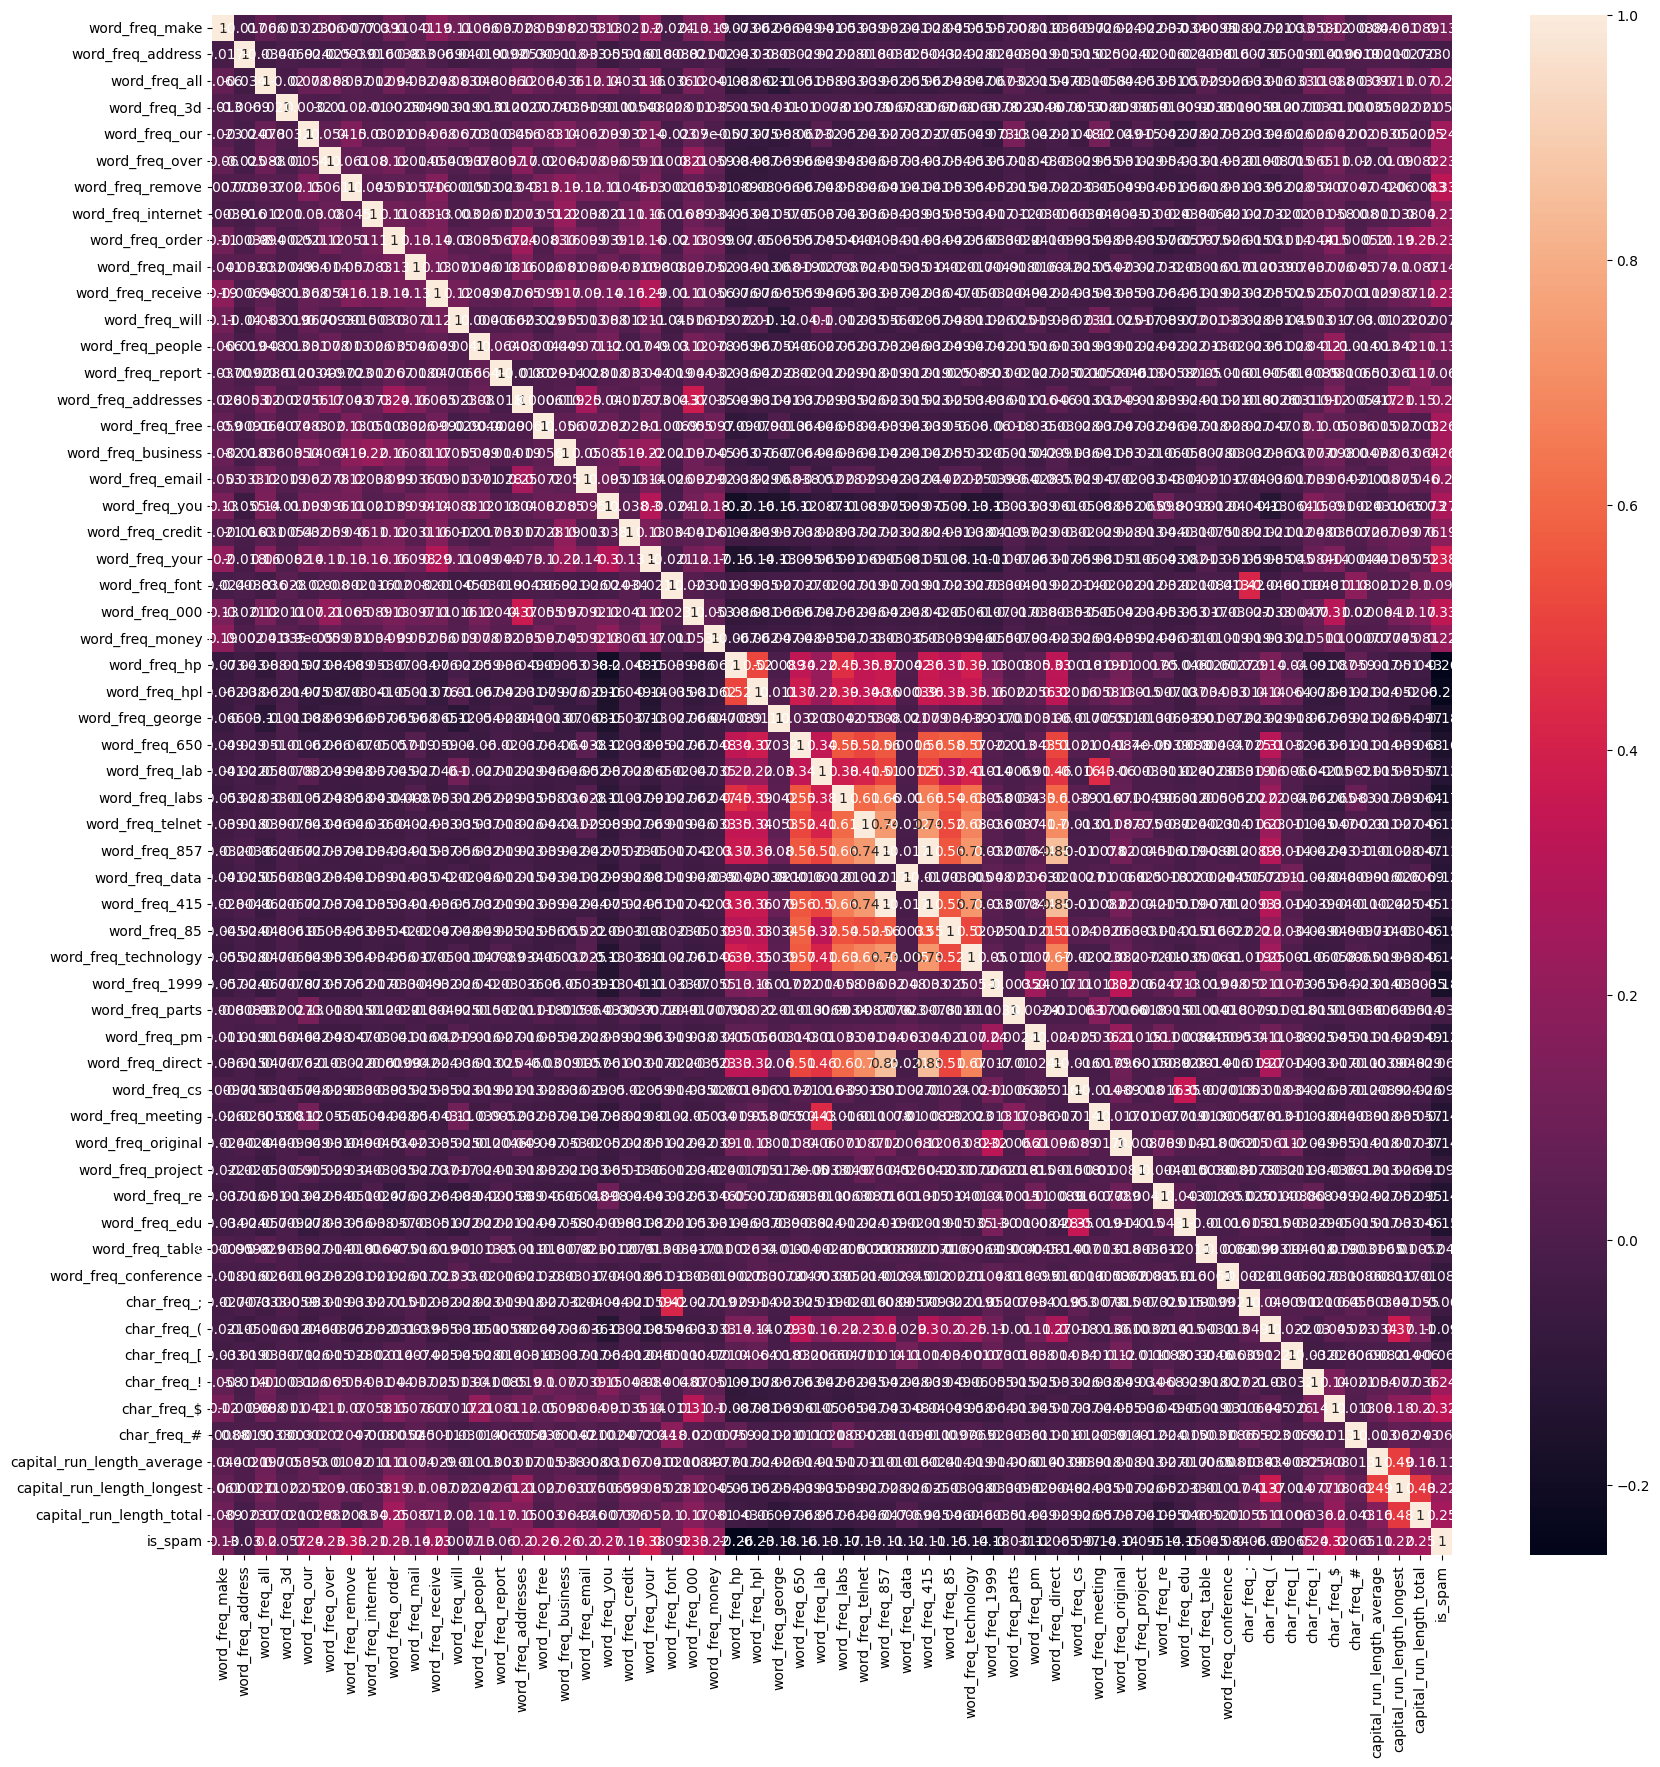

In [12]:
fig,ax = plt.subplots(figsize=(20,20))
sea.heatmap(corr,annot=True,ax=ax)

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [14]:
std_scaler=StandardScaler()

In [15]:
feature =df.drop('is_spam',axis=1)
target = df['is_spam']

In [16]:
features = pd.DataFrame(std_scaler.fit_transform(feature),columns=feature.columns)

In [17]:
print(pd.DataFrame(columns=feature.columns))

Empty DataFrame
Columns: [word_freq_make, word_freq_address, word_freq_all, word_freq_3d, word_freq_our, word_freq_over, word_freq_remove, word_freq_internet, word_freq_order, word_freq_mail, word_freq_receive, word_freq_will, word_freq_people, word_freq_report, word_freq_addresses, word_freq_free, word_freq_business, word_freq_email, word_freq_you, word_freq_credit, word_freq_your, word_freq_font, word_freq_000, word_freq_money, word_freq_hp, word_freq_hpl, word_freq_george, word_freq_650, word_freq_lab, word_freq_labs, word_freq_telnet, word_freq_857, word_freq_data, word_freq_415, word_freq_85, word_freq_technology, word_freq_1999, word_freq_parts, word_freq_pm, word_freq_direct, word_freq_cs, word_freq_meeting, word_freq_original, word_freq_project, word_freq_re, word_freq_edu, word_freq_table, word_freq_conference, char_freq_;, char_freq_(, char_freq_[, char_freq_!, char_freq_$, char_freq_#, capital_run_length_average, capital_run_length_longest, capital_run_length_total]
Index: [

In [18]:
features.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222


In [19]:
target.head()

0    1
1    1
2    1
3    1
4    1
Name: is_spam, dtype: int64

In [20]:
Train_x,Test_x,Train_y,test_y=train_test_split(features,target,test_size=0.2,random_state=42)

In [21]:
Train_x

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
1370,-0.047665,-0.165072,-0.378220,-0.0469,0.115663,-0.021552,-0.061849,-0.262562,0.358714,0.078467,...,-0.111546,-0.158453,-0.000113,-0.155198,0.050184,0.322097,-0.103048,0.051109,2.267291,1.937565
3038,-0.342434,-0.165072,-0.556761,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,0.350902,-0.055601,-0.155198,-0.329912,-0.308355,-0.103048,-0.106900,-0.226678,-0.393034
2361,-0.342434,-0.165072,4.263825,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,0.645879,-0.371364,...,-0.111546,-0.158453,0.758231,-0.155198,-0.329912,-0.308355,-0.103048,-0.090541,-0.206152,-0.191807
156,-0.342434,-0.165072,-0.556761,-0.0469,1.483816,-0.350266,3.055176,3.004044,4.379023,1.660635,...,-0.111546,-0.158453,-0.514307,-0.155198,-0.186457,0.167535,-0.103048,1.365079,0.686751,0.012718
2526,-0.342434,-0.165072,-0.556761,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,-0.329912,-0.308355,-0.103048,-0.090920,-0.226678,-0.417775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,-0.342434,-0.165072,-0.556761,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.063000,0.585324,-0.329912,-0.308355,-0.009872,-0.040992,0.091483,0.065499
466,-0.342434,0.013163,-0.556761,-0.0469,-0.122276,1.366351,-0.291794,0.909427,-0.323302,1.102223,...,-0.111546,-0.158453,-0.066699,0.210492,-0.329912,-0.145658,-0.103048,-0.044491,0.014508,-0.155521
3092,-0.342434,-0.165072,-0.556761,-0.0469,1.751498,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,0.332819,-0.155198,-0.329912,-0.308355,-0.103048,-0.090100,-0.216415,-0.386436
3772,-0.342434,0.013163,-0.556761,-0.0469,-0.464314,0.489780,-0.291794,0.884491,-0.323302,-0.371364,...,-0.111546,0.100332,-0.281255,-0.155198,-0.134960,-0.308355,-0.103048,-0.112700,-0.201020,-0.181911


In [22]:
Train_y

1370    1
3038    0
2361    0
156     1
2526    0
       ..
4426    0
466     1
3092    0
3772    0
860     1
Name: is_spam, Length: 3680, dtype: int64

In [23]:
model=GaussianNB()

In [24]:
model.fit(Train_x,Train_y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [25]:
prediction=model.predict(Test_x)

In [26]:
print(prediction[:10])

[1 0 0 1 0 1 0 0 0 1]


In [27]:
accur = accuracy_score(test_y,prediction)

In [28]:
accur

0.8219326818675353

In [29]:
model.score(Train_x,Train_y)

0.8206521739130435

In [30]:
model.score(Test_x,test_y)

0.8219326818675353

In [31]:
cfs_matric = confusion_matrix(test_y,prediction)

In [32]:
c_matric = pd.DataFrame(
    data=cfs_matric,
    columns=['predicted -ve:0', 'predicted +ve:1'],
    index=['actual -ve:0', 'actual +ve:1']
)

In [33]:
c_matric

,predicted -ve:0,predicted +ve:1
actual -ve:0,391,140
actual +ve:1,24,366


<Axes: >

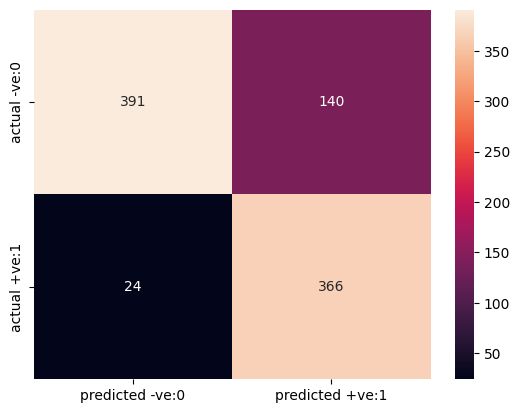

In [34]:
sea.heatmap(c_matric,annot=True,fmt='d')

In [35]:
print(classification_report(test_y,prediction))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83       531
           1       0.72      0.94      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



parameter tuning

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param = {'var_smoothing':[1e-11,1e-9,1e-7,1e-5,1e-3]}
grid = GridSearchCV(GaussianNB(),param,cv=5,scoring='accuracy') 
grid.fit(Train_x,Train_y)

print("best value :",grid.best_params_)
print("best accuracy :",grid.best_score_)

best value : {'var_smoothing': 1e-07}
best accuracy : 0.8168478260869565


In [38]:
test_accuracy = grid.score(Test_x,test_y)
print("Test Accuracy :",test_accuracy)

Test Accuracy : 0.8219326818675353


define log

In [39]:
log_featur=np.log1p(feature)

In [40]:
log_std = StandardScaler()
log_featurs = pd.DataFrame(log_std.fit_transform(log_featur),columns=feature.columns)

In [41]:
log_Train_x,log_Test_x,log_Train_y,log_Test_y = train_test_split(log_featurs,target,test_size=0.2,random_state=42)

In [42]:
log_model = GaussianNB(var_smoothing=1e-7)
log_model.fit(log_Train_x,log_Train_y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-07


In [43]:
log_prediction = log_model.predict(log_Test_x)
print("Test Accuracy :",accuracy_score(log_Test_y,log_prediction))
print(classification_report(log_Test_y,log_prediction))

Test Accuracy : 0.8393051031487514
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       531
           1       0.75      0.94      0.83       390

    accuracy                           0.84       921
   macro avg       0.85      0.85      0.84       921
weighted avg       0.86      0.84      0.84       921

